Enter the constant stepsize ε (e.g., 0.01, 0.05, 0.2): 0.2


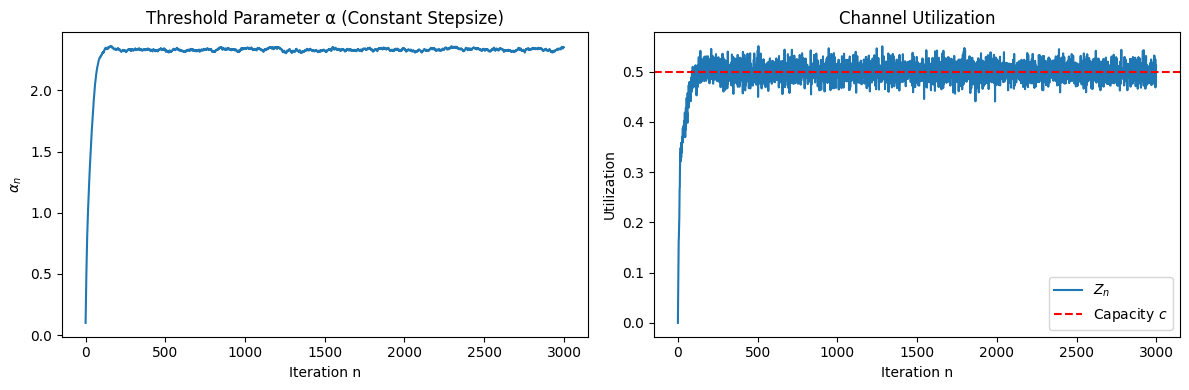

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 4
r = np.array([100, 50, 10, 1])                 # rewards r_j
p = np.array([1/3, 1/12, 1/4, 1/3])            # class probabilities p_j
λ = 1e5                                       # arrival rate
c = 0.5                                       # capacity constraint

T = 0.01                                      # observation window (seconds)
N_iter = 3000                                 # number of iterations


ε = float(input("Enter the constant stepsize ε (e.g., 0.01, 0.05, 0.2): "))

def admit(α, j):
    """
    Threshold policy:
    j < ⌊α⌋   -> admit
    j = ⌊α⌋   -> admit with probability (α - ⌊α⌋)
    j > ⌊α⌋   -> reject
    """
    k = int(np.floor(α))
    if j < k:
        return 1
    elif j == k:
        return np.random.rand() < (α - k)
    else:
        return 0


α = 0.0                                      # initial estimate
α_history = []
Z_history = []

for n in range(1, N_iter + 1):

    # arrivals in window T (Poisson process)
    arrivals = np.random.poisson(λ * T)
    admitted = 0

    for _ in range(arrivals):
        j = np.random.choice(N, p=p)
        admitted += admit(α, j)

    # utilization estimate Z_n
    Z_n = admitted / arrivals if arrivals > 0 else 0.0

    # Robbins–Monro update with constant stepsize
    α = α + ε * (c - Z_n)

    # projection (truncation to admissible set)
    α = np.clip(α, 0, N)

    # store history
    α_history.append(α)
    Z_history.append(Z_n)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(α_history)
plt.xlabel("Iteration n")
plt.ylabel(r"$\alpha_n$")
plt.title("Threshold Parameter α (Constant Stepsize)")

plt.subplot(1, 2, 2)
plt.plot(Z_history, label=r"$Z_n$")
plt.axhline(c, color="red", linestyle="--", label=r"Capacity $c$")
plt.xlabel("Iteration n")
plt.ylabel("Utilization")
plt.legend()
plt.title("Channel Utilization")

plt.tight_layout()
plt.show()
